# NB03 - Metricas, calibracion y bondad de ajuste

**Objetivos de aprendizaje**

- Evaluar un clasificador logistico mas alla del accuracy.
- Interpretar matriz de confusion, ROC-AUC y curvas precision-recall.
- Revisar calibracion probabilistica.
- Implementar desde cero el test de Hosmer-Lemeshow.
- Ver como el umbral de decision cambia precision y recall.

**Referencias de este notebook**

- Hosmer & Lemeshow (1980): proponen el test de bondad de ajuste implementado aqui.
- Hosmer, Lemeshow & Sturdivant (2013): sistematizan diagnostico y evaluacion de modelos logisticos.
- He & Garcia (2009): explican por que ROC y precision-recall son importantes, especialmente con desbalance.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from scipy.stats import chi2
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


## 1. Modelo base y matriz de confusion

Ajustamos una regresion logistica L2 moderada sobre los splits compartidos. La matriz de confusion separa aciertos y errores por clase, lo que permite derivar metricas como precision, recall, F1 y especificidad.


,metrica,valor
0,accuracy,0.9000
1,precision,0.9286
2,recall/sensibilidad,0.8667
3,F1,0.8966
4,especificidad,0.9333


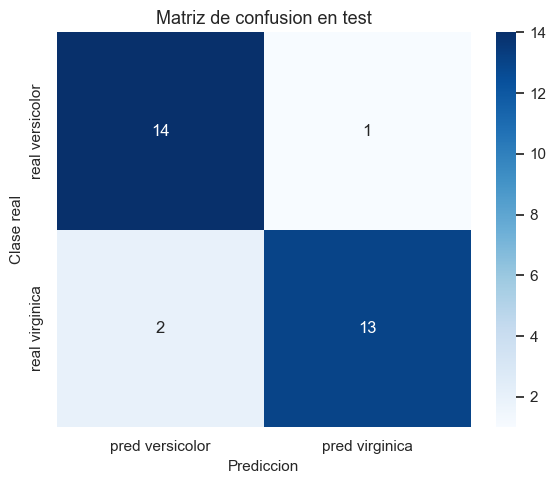

In [2]:
data = load_processed_splits(DATA_DIR)
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]

# Modelo base reproducible; C=1 deja regularizacion L2 moderada.
model = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
metrics_table = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision", "recall/sensibilidad", "F1", "especificidad"],
        "valor": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            tn / (tn + fp),
        ],
    }
)
display(metrics_table.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred versicolor", "pred virginica"],
    yticklabels=["real versicolor", "real virginica"],
    ax=ax,
)
ax.set_title("Matriz de confusion en test")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Clase real")
fig.tight_layout()
plt.show()


**Interpretacion.** El accuracy resume todos los aciertos, pero precision y recall distinguen tipos de error. En problemas reales, confundir una clase puede ser mucho mas costoso que confundir la otra.


## 2. Curva ROC y AUC

La curva ROC evalua todos los umbrales posibles comparando tasa de verdaderos positivos contra tasa de falsos positivos.


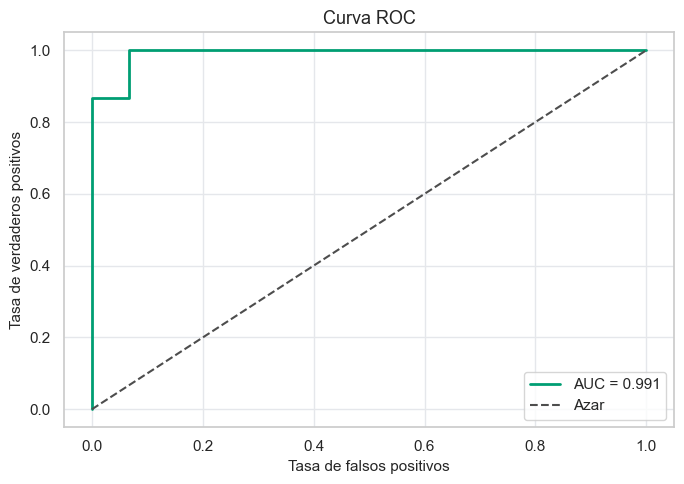

In [3]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color=COLOR_PALETTE["decision"], linewidth=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color=COLOR_PALETTE["neutral"], linestyle="--", label="Azar")
ax.set_title("Curva ROC")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretacion.** Un AUC cercano a 1 indica buen ordenamiento probabilistico: las `virginica` tienden a recibir probabilidades mayores que las `versicolor`. He & Garcia (2009) recomiendan mirar este tipo de metricas cuando la distribucion de clases importa.


## 3. Curva precision-recall

La curva PR se concentra en la calidad de las predicciones positivas. Suele ser mas informativa que ROC cuando una clase es rara, tema que retomaremos en NB08.


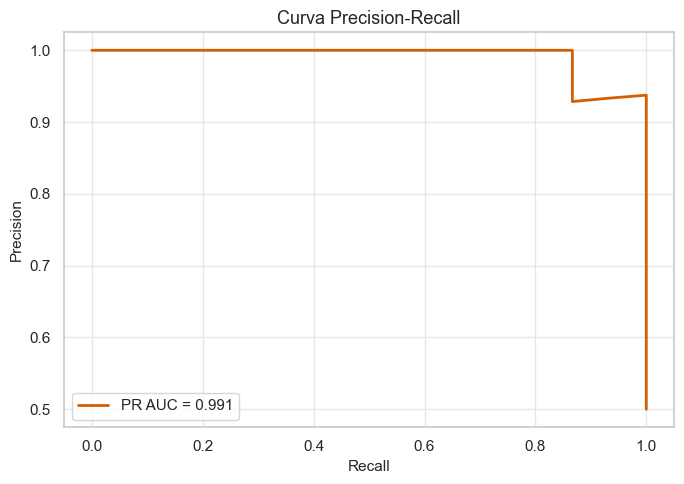

In [4]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color=COLOR_PALETTE["virginica"], linewidth=2, label=f"PR AUC = {pr_auc:.3f}")
ax.set_title("Curva Precision-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretacion.** Precision y recall se mueven en tension: al exigir menos evidencia para predecir `virginica`, sube el recall pero puede caer la precision. Esta tension es central en decisiones con costo.


## 4. Calibracion

Un modelo calibrado no solo ordena bien, tambien asigna probabilidades realistas. Si predice 0.8 para un grupo de observaciones, esperamos que cerca del 80% sean positivas.


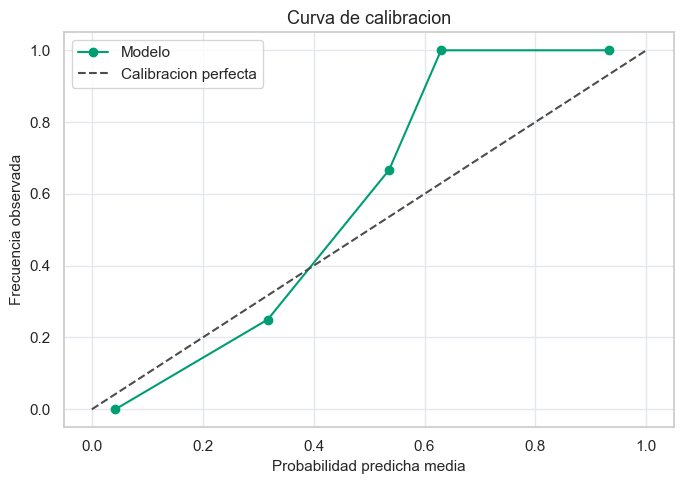

In [5]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5, strategy="uniform")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, marker="o", color=COLOR_PALETTE["decision"], label="Modelo")
ax.plot([0, 1], [0, 1], color=COLOR_PALETTE["neutral"], linestyle="--", label="Calibracion perfecta")
ax.set_title("Curva de calibracion")
ax.set_xlabel("Probabilidad predicha media")
ax.set_ylabel("Frecuencia observada")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretacion.** La muestra de test es pequena, asi que la curva puede verse escalonada. Aun asi, el grafico ilustra la pregunta de calibracion: si las probabilidades estimadas coinciden con frecuencias observadas.


## 5. Test de Hosmer-Lemeshow desde cero

Hosmer & Lemeshow (1980) agrupan observaciones por riesgo predicho y comparan eventos observados contra esperados. Un p-valor pequeno sugiere falta de ajuste; un p-valor grande no prueba que el modelo sea perfecto, solo que el test no detecta discrepancias fuertes.


In [6]:
def hosmer_lemeshow_test(y_true, y_probability, groups=10):
    # Ordenamos por riesgo predicho y formamos grupos con tamanos
    # similares. qcut puede fusionar grupos si hay probabilidades repetidas.
    df = pd.DataFrame({"y": y_true, "p": y_probability}).sort_values("p")
    df["group"] = pd.qcut(df["p"], q=groups, duplicates="drop")

    grouped = df.groupby("group", observed=True)
    observed_events = grouped["y"].sum()
    expected_events = grouped["p"].sum()
    n_group = grouped.size()
    observed_nonevents = n_group - observed_events
    expected_nonevents = n_group - expected_events

    # Estadistico chi-cuadrado con proteccion numerica para grupos pequenos.
    eps = 1e-12
    statistic = (
        ((observed_events - expected_events) ** 2 / np.maximum(expected_events, eps))
        + ((observed_nonevents - expected_nonevents) ** 2 / np.maximum(expected_nonevents, eps))
    ).sum()
    dof = max(len(observed_events) - 2, 1)
    p_value = 1 - chi2.cdf(statistic, dof)

    table = pd.DataFrame(
        {
            "n": n_group,
            "observados_evento": observed_events,
            "esperados_evento": expected_events,
            "observados_no_evento": observed_nonevents,
            "esperados_no_evento": expected_nonevents,
        }
    )
    return statistic, dof, p_value, table


hl_stat, hl_dof, hl_p, hl_table = hosmer_lemeshow_test(y_test, y_prob, groups=10)
print(f"HL chi2 = {hl_stat:.3f}, gl = {hl_dof}, p-valor = {hl_p:.3f}")
display(hl_table.round(3))


HL chi2 = 2.366, gl = 8, p-valor = 0.968


,n,observados_evento,esperados_evento,observados_no_evento,esperados_no_evento
group,,,,,
"(0.00049, 0.00792]",3,0,0.006,3,2.994
"(0.00792, 0.0259]",3,0,0.046,3,2.954
"(0.0259, 0.118]",3,0,0.120,3,2.880
"(0.118, 0.25]",3,0,0.540,3,2.460
"(0.25, 0.445]",3,1,1.022,2,1.978
"(0.445, 0.605]",3,2,1.608,1,1.392
"(0.605, 0.872]",3,3,2.345,0,0.655
"(0.872, 0.911]",3,3,2.701,0,0.299
"(0.911, 0.977]",3,3,2.866,0,0.134


**Interpretacion.** El test compara riesgos predichos con eventos observados por deciles. En muestras pequenas debe leerse con cautela, pero es una herramienta clasica de diagnostico en la tradicion de Hosmer, Lemeshow & Sturdivant (2013).


## 6. El umbral de decision

La probabilidad es continua; la clase final depende de un umbral. Cambiarlo altera el balance entre precision y recall.


,threshold,precision,recall,f1
0,0.10,0.714,1.000,0.833
1,0.15,0.789,1.000,0.882
2,0.20,0.789,1.000,0.882
3,0.25,0.833,1.000,0.909
4,0.30,0.882,1.000,0.938
5,0.35,0.882,1.000,0.938
6,0.40,0.933,0.933,0.933
7,0.45,0.933,0.933,0.933
8,0.50,0.929,0.867,0.897
9,0.55,1.000,0.867,0.929


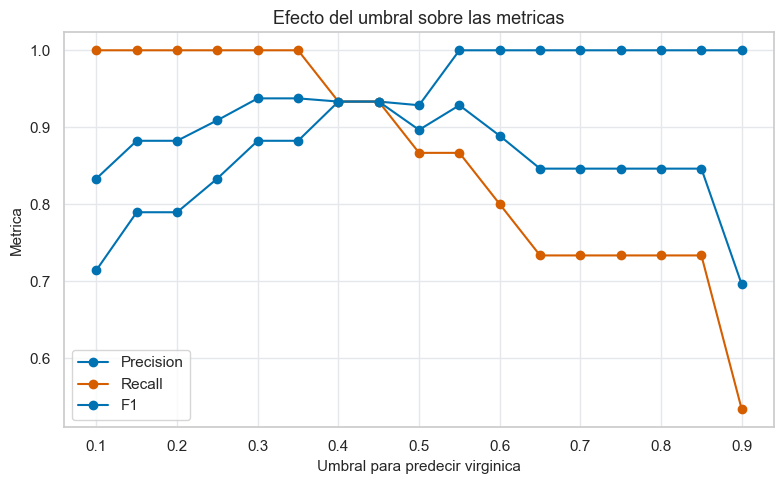

In [7]:
threshold_rows = []
for threshold in np.linspace(0.1, 0.9, 17):
    pred_threshold = (y_prob >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, pred_threshold, zero_division=0),
            "recall": recall_score(y_test, pred_threshold, zero_division=0),
            "f1": f1_score(y_test, pred_threshold, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
ax.set_title("Efecto del umbral sobre las metricas")
ax.set_xlabel("Umbral para predecir virginica")
ax.set_ylabel("Metrica")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretacion.** Un umbral bajo predice mas positivos y suele elevar recall; un umbral alto exige mas evidencia y puede elevar precision. La decision optima depende del costo relativo de cada error.


## Resumen y conexion con la literatura

Hosmer & Lemeshow (1980) aportan el test de bondad de ajuste implementado aqui mediante grupos de riesgo. Hosmer, Lemeshow & Sturdivant (2013) dan el marco aplicado para diagnosticar modelos logisticos con confusion, calibracion y ajustes de umbral. He & Garcia (2009) conectan ROC y precision-recall con el problema de clases desbalanceadas que abordaremos en NB08.
